### Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

### Data Collection

In [2]:
# Import dataset
original_df = pd.read_csv("Project_Resources/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("\nOriginal DataFrame: \n", original_df.head())

# Check data types of all the features.
print("\nData types: \n", original_df.dtypes)

# Check for missing values and get count of Non-nulls.
print("\nTotal nulls in each feature: \n", original_df.isnull().sum())
# No need to take count of non-nulls as there are no nulls in this dataset.

# Target variables for survival analysis are already identified and present
# in the dataset:
# duration = tenure; event = churn
# Make feature names cases consistent
original_df.columns = original_df.columns.str.lower()

# Convert to float, replacing any non-numeric values with NaN
original_df['totalcharges'] = pd.to_numeric(original_df['totalcharges'],
                                   errors='coerce')

# Change the data types wherever required
original_df["totalcharges"] = original_df["totalcharges"].astype(float)

# Check new data types of all the features.
print("\nNew data types: \n", original_df.dtypes)


Original DataFrame: 
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovi

### EDA


Unique values in "churn" column: 
 churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rates (%): 
 churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


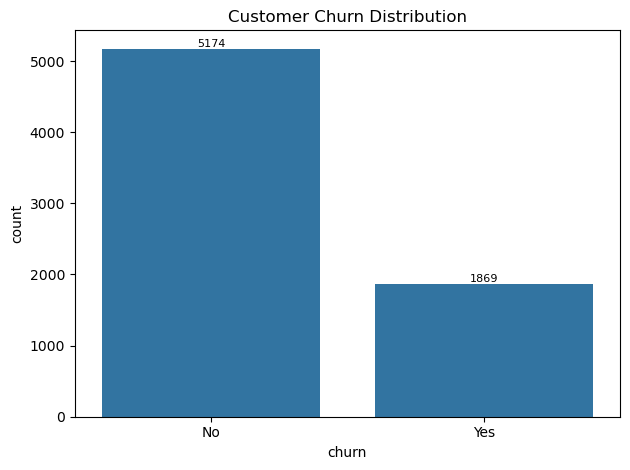

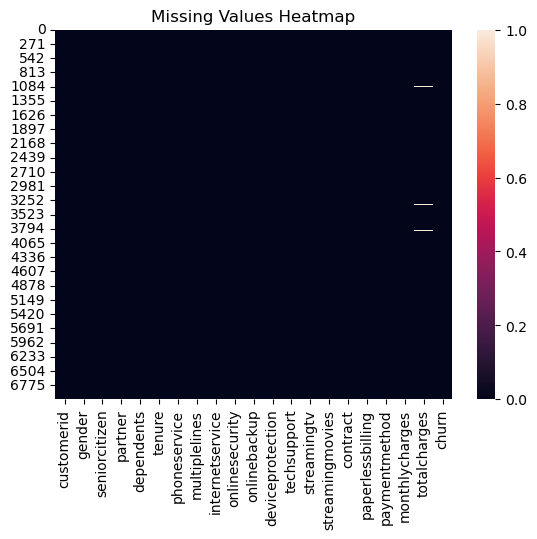

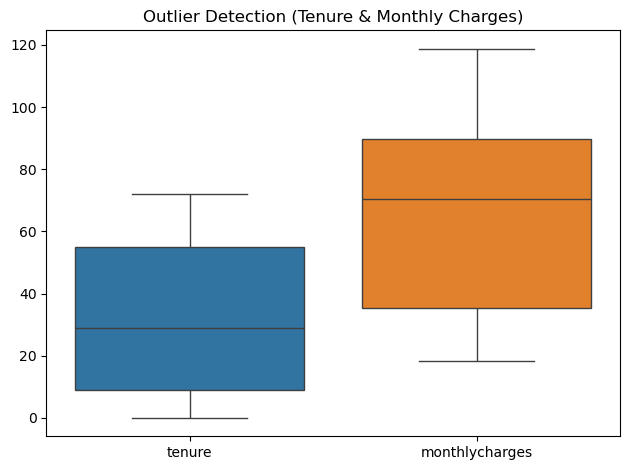

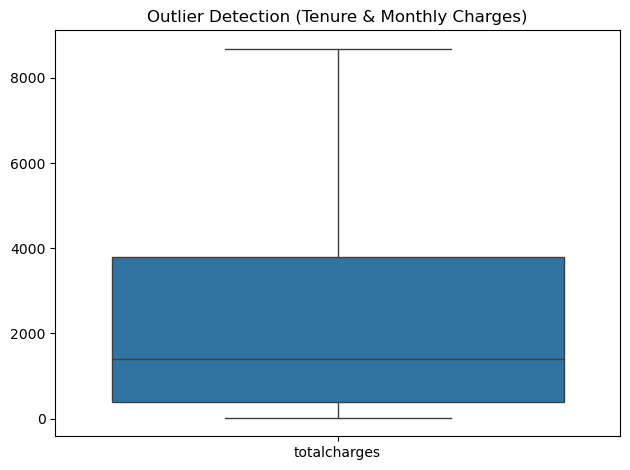

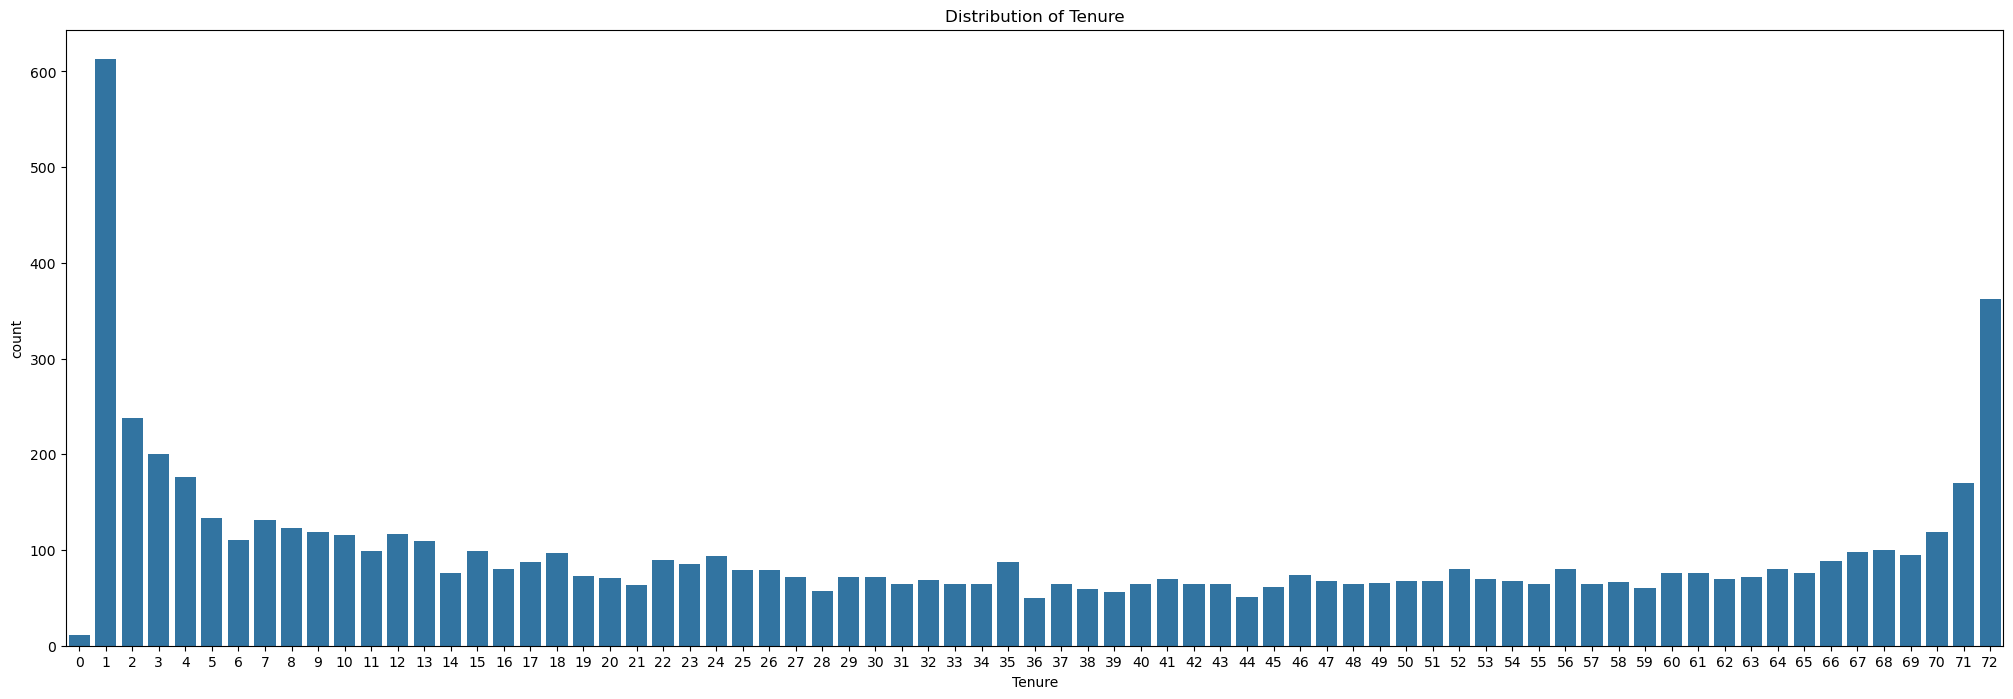

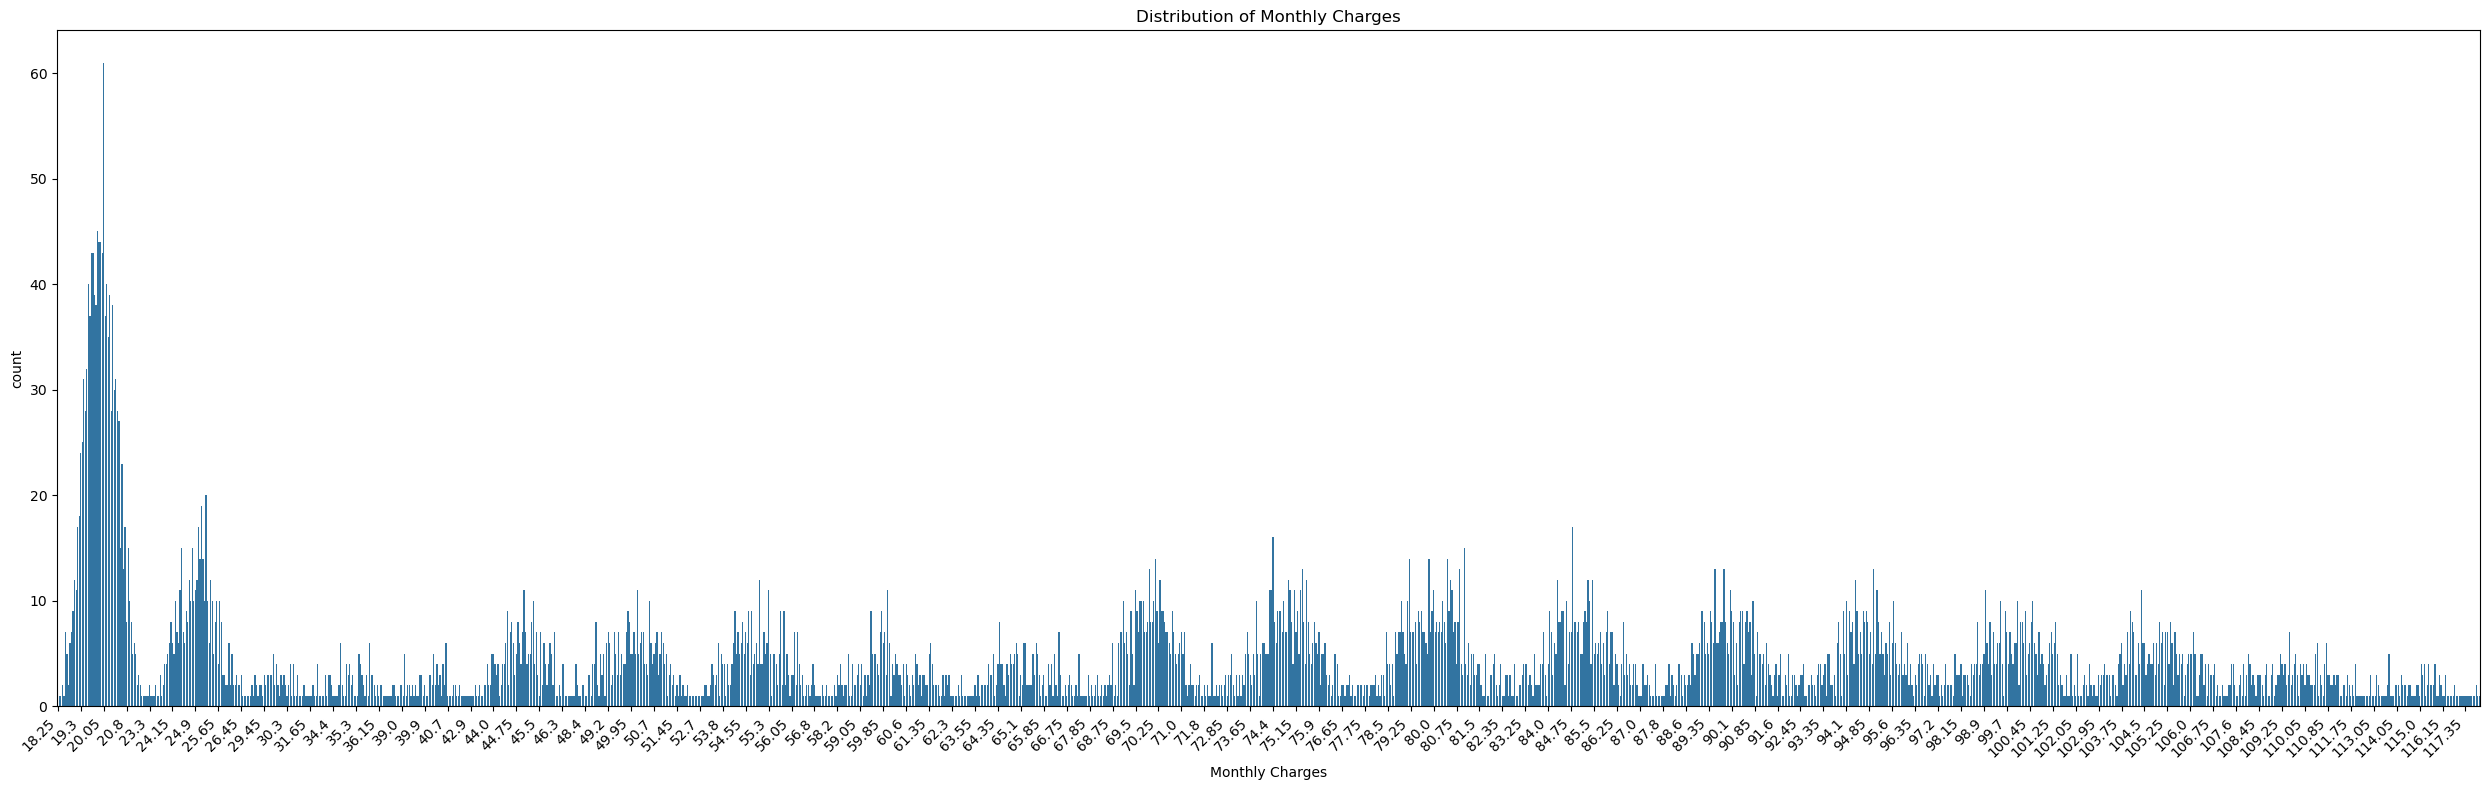

In [3]:
# Check the churn rate
print('\nUnique values in "churn" column: \n',\
      original_df["churn"].value_counts())
churn_rate = original_df["churn"].value_counts(normalize=True) * 100
print("\nChurn Rates (%): \n", churn_rate.round(2))

# Visualize churn distribution
ax = sns.countplot(data=original_df, x="churn")
ax.bar_label(ax.containers[0], fontsize=8, fmt='%.0f')
plt.title("Customer Churn Distribution")
plt.tight_layout()
plt.show()

# Visualize the missing data
sns.heatmap(original_df.isna(), cbar=True)
plt.title("Missing Values Heatmap")
plt.show()
# There is no missing data

# Detect outliers
num_cols1 = ['tenure', 'monthlycharges']
sns.boxplot(data=original_df[num_cols1])
plt.title('Outlier Detection (Tenure & Monthly Charges)')
plt.tight_layout()
plt.show()

# totalcharges column has much bigger range so it is plotted separately.
num_cols2 = ['totalcharges']
sns.boxplot(data=original_df[num_cols2])
plt.title('Outlier Detection (Tenure & Monthly Charges)')
plt.tight_layout()
plt.show()
# There are no outliers in any of these features.

# Visualize distribution of tenure
plt.figure(figsize=(25, 8))
sns.countplot(data=original_df, x="tenure")
plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.show()

# Visualize distribution of monthly charges
plt.figure(figsize=(25, 8))
ax = sns.countplot(data=original_df, x="monthlycharges")
ax.xaxis.set_major_locator(ticker.MultipleLocator(15))
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Churn Proportions (Part of EDA)

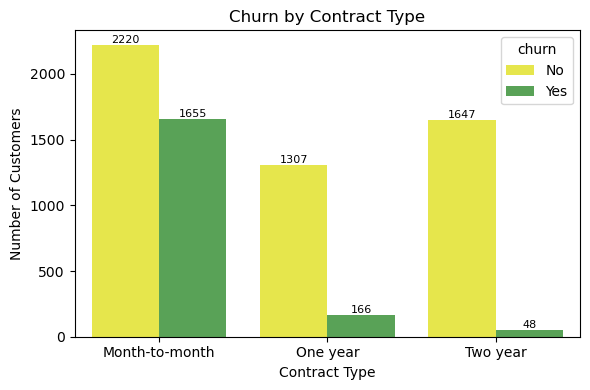

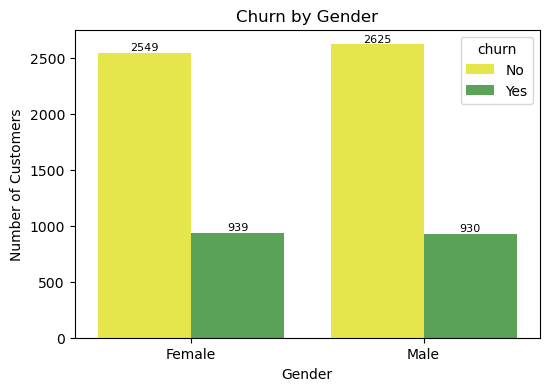

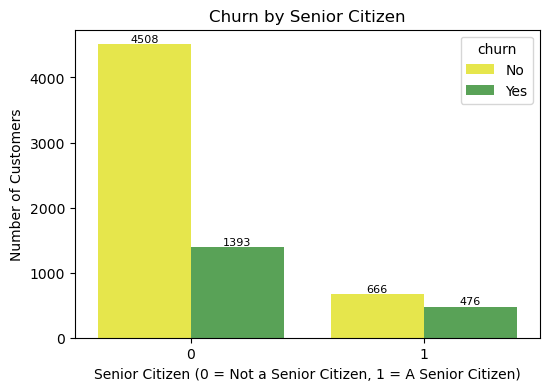

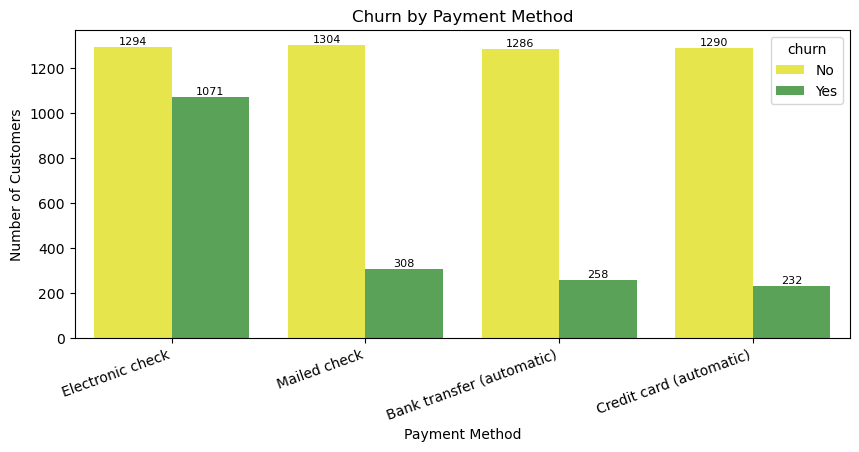

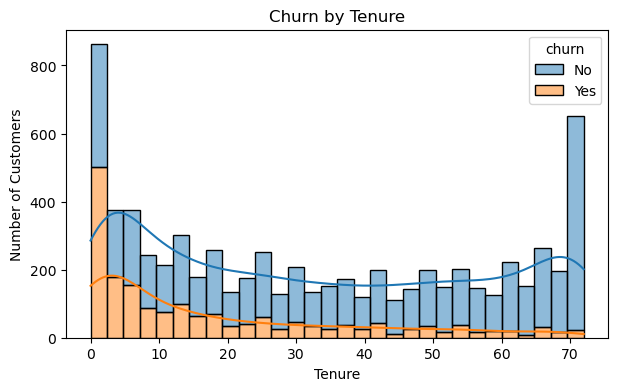

In [4]:
# 1. Churn proportion by contract type
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=original_df, x="contract", hue="churn",\
                   palette="Set1_r")
# Loop through all bar containers and add labels to each one
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 2. Churn proportion by gender
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=original_df, x="gender", hue="churn",
                   palette="Set1_r")
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# 3. Churn proportion by senior citizen
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=original_df, x="seniorcitizen", hue="churn",
                   palette="Set1_r")
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.title("Churn by Senior Citizen")
plt.xlabel("Senior Citizen (0 = Not a Senior Citizen, 1 = A Senior Citizen)")
plt.ylabel("Number of Customers")
plt.show()

# 4. Churn proportion by payment method
plt.figure(figsize=(10, 4))
ax = sns.countplot(data=original_df, x="paymentmethod", hue="churn",
                   palette="Set1_r")
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of Customers")
plt.show()

# 5. Churn proportion by tenure
plt.figure(figsize=(7, 4))
sns.histplot(data=original_df, x="tenure", hue="churn", bins=30,
             kde=True, multiple="stack")
plt.title("Churn by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()